<a href="https://colab.research.google.com/github/lunecarvalho/ml-ai-studies/blob/main/02_ia_challenge_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_daily_top_10.csv")

In [3]:
df.head()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55


In [4]:
df.shape

(7100, 10)

In [6]:
tipos_dados = pd.DataFrame({
    "Coluna": df.columns,
    "Tipo de dado": df.dtypes.values
})

tipos_dados

,Coluna,Tipo de dado
0,As of,object
1,Rank,int64
2,Year to Date Rank,object
3,Last Week Rank,object
4,Title,object
5,Type,object
6,Netflix Exclusive,object
7,Netflix Release Date,object
8,Days In Top 10,int64
9,Viewership Score,int64


Em tipos de objetos, temos:

*   2 variáveis numéricas inteiras
*   8 variáveis categorias/textuais



In [7]:
df["As of"] = pd.to_datetime(df["As of"])

df["Netflix Release Date"] = pd.to_datetime(
    df["Netflix Release Date"],
    errors="coerce"
)

In [8]:
df.dtypes

,0
As of,datetime64[ns]
Rank,int64
Year to Date Rank,object
Last Week Rank,object
Title,object
Type,object
Netflix Exclusive,object
Netflix Release Date,datetime64[ns]
Days In Top 10,int64
Viewership Score,int64


Como as colunas de data estão como *object*, com *pd.to_datetime* transformamos elas em tipo data.



In [9]:
data_inicial = df["As of"].min()
data_final = df["As of"].max()

print("Data inicial:", data_inicial.strftime("%d/%m/%Y"))
print("Data final:", data_final.strftime("%d/%m/%Y"))

Data inicial: 01/04/2020
Data final: 11/03/2022


A coluna *As of* representa a data referente ao ranking diário.

A base contempla aproximadamente:
**01 de abril de 2020 a 11 de março de 2022.**

In [15]:
# Dias distintos

print(f"Período analisado: {data_inicial:%d/%m/%Y} a {data_final:%d/%m/%Y}")
print(f"Quantidade de dias distintos: {df['As of'].nunique()}")

Período analisado: 01/04/2020 a 11/03/2022
Quantidade de dias distintos: 710


In [16]:
# Tamanho da base de dados

print("Quantidade de registros:", df.shape[0])
print("Quantidade de variáveis:", df.shape[1])
print("Total de células:", df.size)

Quantidade de registros: 7100
Quantidade de variáveis: 10
Total de células: 71000


In [18]:
# Verificar dados nulos

df.isnull().sum()

,0
As of,0
Rank,0
Year to Date Rank,0
Last Week Rank,0
Title,0
Type,0
Netflix Exclusive,2501
Netflix Release Date,0
Days In Top 10,0
Viewership Score,0


In [19]:
nulos = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Percentual (%)": df.isnull().mean() * 100
})

nulos

,Valores nulos,Percentual (%)
As of,0,0.000000
Rank,0,0.000000
Year to Date Rank,0,0.000000
Last Week Rank,0,0.000000
Title,0,0.000000
Type,0,0.000000
Netflix Exclusive,2501,35.225352
Netflix Release Date,0,0.000000
Days In Top 10,0,0.000000
Viewership Score,0,0.000000


Apenas uma coluna apresenta valores nulos:

*Netflix Exclusive* - *2.501 valores nulos*

In [20]:
percentual_nulos = (df["Netflix Exclusive"].isnull().sum() / len(df)) * 100

print(f"Percentual de valores nulos: {percentual_nulos:.2f}%")

Percentual de valores nulos: 35.23%


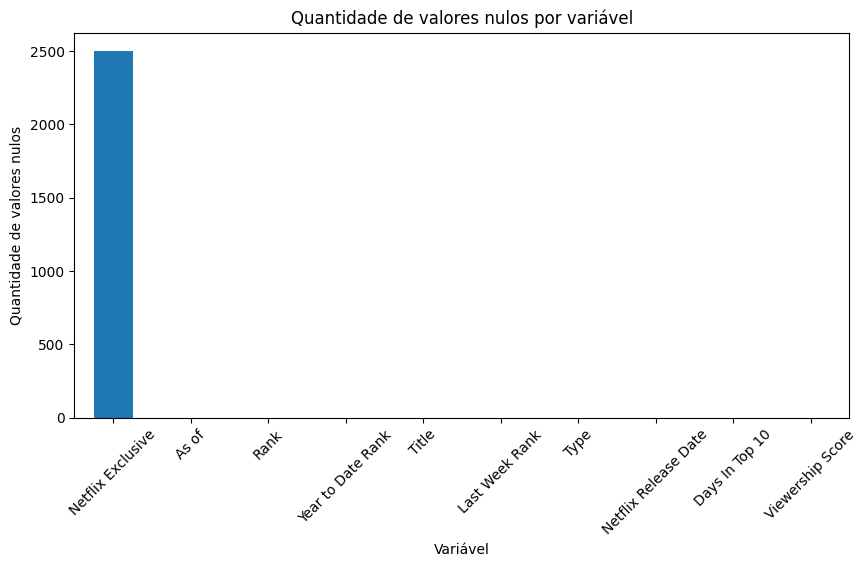

In [21]:
plt.figure(figsize=(10, 5))

df.isnull().sum().sort_values(ascending=False).plot(kind="bar")

plt.title("Quantidade de valores nulos por variável")
plt.xlabel("Variável")
plt.ylabel("Quantidade de valores nulos")
plt.xticks(rotation=45)
plt.show()

In [22]:
# Verificar duplicidade

duplicatas = df.duplicated().sum()

print("Quantidade de registros duplicados:", duplicatas)

Quantidade de registros duplicados: 0


### Identificação de outliers:

In [23]:
df[["Rank", "Days In Top 10", "Viewership Score"]].describe()

,Rank,Days In Top 10,Viewership Score
count,7100.000000,7100.000000,7100.000000
mean,5.500000,24.123662,122.790141
std,2.872484,58.473789,213.861642
min,1.000000,1.000000,1.000000
25%,3.000000,3.000000,19.000000
50%,5.500000,7.000000,50.000000
75%,8.000000,18.000000,128.000000
max,10.000000,428.000000,1474.000000


In [24]:
def detectar_outliers(df, coluna):
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    print(f"Variável: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Quantidade de outliers: {len(outliers)}")

    return outliers

In [25]:
outliers_rank = detectar_outliers(df, "Rank")

Variável: Rank
Q1: 3.0
Q3: 8.0
IQR: 5.0
Limite inferior: -4.5
Limite superior: 15.5
Quantidade de outliers: 0


In [26]:
outliers_dias = detectar_outliers(df, "Days In Top 10")

Variável: Days In Top 10
Q1: 3.0
Q3: 18.0
IQR: 15.0
Limite inferior: -19.5
Limite superior: 40.5
Quantidade de outliers: 743


In [27]:
outliers_score = detectar_outliers(df, "Viewership Score")

Variável: Viewership Score
Q1: 19.0
Q3: 128.0
IQR: 109.0
Limite inferior: -144.5
Limite superior: 291.5
Quantidade de outliers: 698


### Visualizar os outliers com **boxplots**:

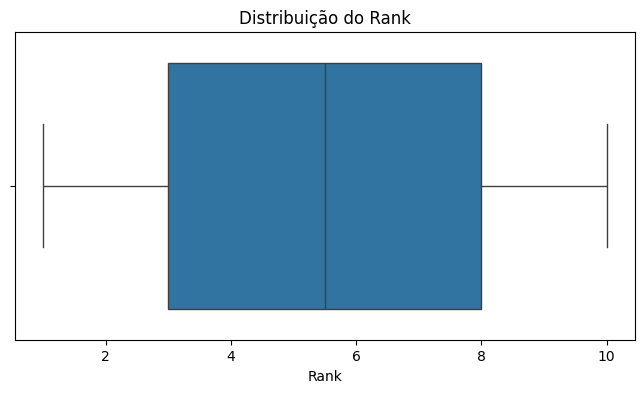

In [28]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Rank"])

plt.title("Distribuição do Rank")
plt.xlabel("Rank")

plt.show()

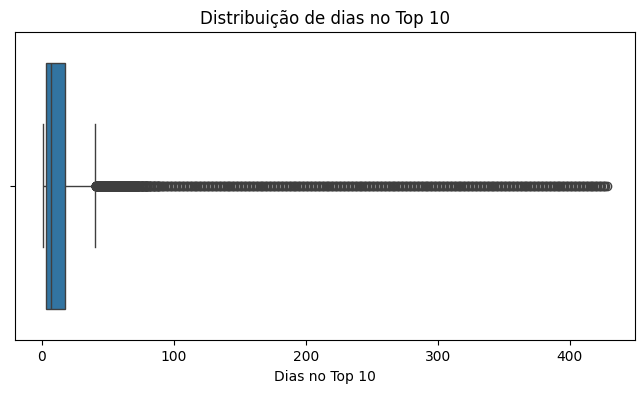

In [29]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Days In Top 10"])

plt.title("Distribuição de dias no Top 10")
plt.xlabel("Dias no Top 10")

plt.show()

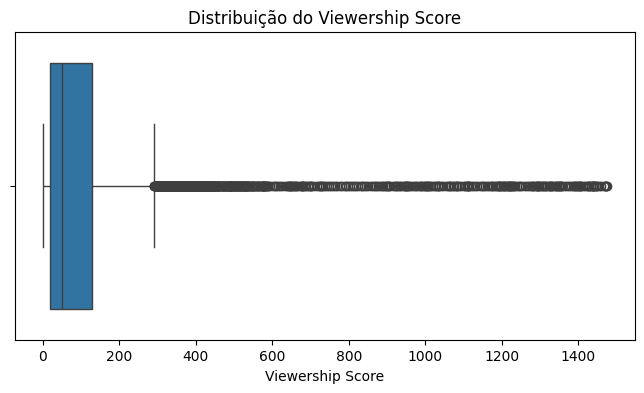

In [30]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Viewership Score"])

plt.title("Distribuição do Viewership Score")
plt.xlabel("Viewership Score")

plt.show()

In [31]:
variaveis_numericas = [
    "Rank",
    "Days In Top 10",
    "Viewership Score"
]

resultado_outliers = []

for coluna in variaveis_numericas:

    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    quantidade = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ).sum()

    resultado_outliers.append({
        "Variável": coluna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
        "Quantidade de outliers": quantidade
    })

resultado_outliers = pd.DataFrame(resultado_outliers)

resultado_outliers

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Quantidade de outliers
0,Rank,3.0,8.0,5.0,-4.5,15.5,0
1,Days In Top 10,3.0,18.0,15.0,-19.5,40.5,743
2,Viewership Score,19.0,128.0,109.0,-144.5,291.5,698
